# NeuralMag vortex `Msat` fit with differentiable LLG

This notebook is an end-to-end smoke test for fitting a magnetic material parameter through a differentiable micromagnetic simulation. It builds a simple cylindrical vortex, evolves it with NeuralMag using the JAX backend, projects the magnetization through the LiberTEM-holo MBIR phase model, and asks whether a scalar optimizer can recover the target saturation magnetization `Msat` from the phase image.

The steps are as follows:

1. define a cylinder, material constants, and two `Msat` cases;
2. create a vortex-like initial magnetization field on the cylinder support;
3. evolve both cases with the same fixed-time NeuralMag `LLGSolver.solve()` horizon;
4. choose the 800 kA/m phase image as the target and the 300 kA/m magnetization as the input state;
5. differentiate a scalar phase loss through another fixed-time LLG solve and update `Msat` with Adam.

The key constraint is the fixed step ODE solve of the LLG method. `LLGSolver.relax()` is normally the primary solver to converge the LLG equation to a minimum, but its internal stopping rule means it's not immediately compatible with JAX differentiation for gradients to then decide how to update the material parameters. The notebook uses `LLGSolver.solve()` with fixed solve steps so JAX can differentiate through the computation. However, the computation is still slow, and a large amount of steps are needed to get close to a minimum. 

As a result with a fixed solve and a low amount of steps, the states we are calculating are not guaranteed to be a fully relaxed equilibrium. However, for a proof of concept, the approach is still valid because we are comparing the same fixed-time states on both sides of the loss function, so the gradients should still be meaningful for optimization.

For quick sharing, this notebook also supports Google Colab. Open it from the `mag_inversion` branch, switch to a GPU runtime if one is available, run the next bootstrap cell once, and then use `Runtime -> Run all`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LiberTEM/LiberTEM-holo/blob/mag_inversion/notebooks/MBIR/neuralmag_vortex_fit_llg.ipynb)


In [9]:
import os
import pathlib
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
LIBERTEM_HOLO_GIT_REF = "mag_inversion"
NEURALMAG_GIT_URL = "https://github.com/DavidLanders95/NeuralMagFork.git"
NEURALMAG_GIT_REF = "3ecee9aece12e04611bd9c302ad7a0814e363046"
READY_FLAG = pathlib.Path("/content/.neuralmag_vortex_fit_colab_ready")

if IN_COLAB:
    if READY_FLAG.exists():
        print("Colab bootstrap already completed for this session.")
    else:
        print("Installing LiberTEM-holo and NeuralMag for Colab ...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-U",
            "pip",
            "setuptools",
            "wheel",
        ])
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            f"libertem-holo @ git+https://github.com/LiberTEM/LiberTEM-holo.git@{LIBERTEM_HOLO_GIT_REF}",
            f"neuralmag[jax] @ git+{NEURALMAG_GIT_URL}@{NEURALMAG_GIT_REF}",
        ])
        READY_FLAG.write_text("ok\n")
        print("Dependencies installed. Colab will restart once so the imports below see the new packages.")
        os.kill(os.getpid(), 9)
else:
    print("Local environment detected; skipping Colab bootstrap.")


Local environment detected; skipping Colab bootstrap.


In [10]:
import importlib.metadata as md

import jax
import optax
import quaxed
import unxt as u
import neuralmag as nm
import libertem_holo

print("Environment check passed.")
print(f"Python: {sys.version.split()[0]}")
print(f"libertem-holo: {md.version('libertem-holo')}")
print(f"neuralmag: {md.version('neuralmag')}")
print(f"jax: {jax.__version__}")
print(f"optax: {optax.__version__}")
print(f"unxt: {md.version('unxt')}")
print(f"quaxed: {md.version('quaxed')}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")
print(f"JAX devices: {jax.devices()}")


Environment check passed.
Python: 3.12.12
libertem-holo: 0.2.0.dev0
neuralmag: 0.9.4
jax: 0.10.0
optax: 0.2.8
unxt: 1.11.1
quaxed: 0.10.4
NeuralMag backend: jax
JAX devices: [CudaDevice(id=0)]


In [1]:
import os
import time

# JAX reads these process flags during import, so they must be set before
# importing JAX, Optax, or NeuralMag. X64 is useful here because LLG dynamics
# and phase accumulation can be sensitive to small numerical differences.
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import unxt as u

from libertem_holo.base.mbir import MU_0, phase_from_magnetisation
import neuralmag as nm

# NeuralMag can use several backends. The fit below differentiates through the
# solver, so the notebook explicitly selects the JAX backend and float64 tensors.
nm.config.backend = "jax"
nm.config.dtype = "float64"

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)


2026-05-06 10:11:02 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-05-06 10:11:02 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-05-06 10:11:02 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


## Geometry And Run Controls

This cell collects the parameters that most affect runtime and interpretation. The spatial grid describes a 320 nm diameter, 20 nm thick disc sampled as `(x, y, z)` cells. The material constants are deliberately simple: exchange and demagnetization are active, while DMI and uniaxial anisotropy are set to zero so the main variable of interest is `Msat`.

The LLG settings are shared between target generation and fitting so both sides of the comparison mean the same thing: evolve a vortex for `llg_solve_time_s`, with an adaptive solver capped by the specified maximum steps. Raising the maximum step counts can move the states closer to equilibrium, but it also makes each differentiable optimization step more expensive.


In [2]:
shape_xyz = (64, 64, 20)
cellsize_nm_xyz = np.array([5.0, 5.0, 1.0], dtype=np.float64)
diameter_nm = 320.0
thickness_nm = 20.0

material = {
    "A_J_per_m": 1.0e-11,
    "Di_J_per_m2": 0.0,
    "Ku_J_per_m3": 0.0,
    "alpha": 1.0,
}

msat_cases = {
    "800 kA/m": 800e3,
    "300 kA/m": 300e3,
}

target_case = "800 kA/m"
input_case = "300 kA/m"

# These settings intentionally favor a reproducible differentiable demo over a
# fully converged micromagnetic study. A fixed integration interval is important
# because JAX can differentiate through a stable sequence of solver operations.
llg_solve_time_s = 1.1e-10
llg_max_steps = 4096
fit_llg_max_steps = 4096
fit_llg_dt0_s = 2e-14

# NeuralMag's demagnetization field uses an approximation order/parameter `p`.
# Keeping it explicit makes it easy to trade accuracy for speed later.
demag_p = 3

# The outer fit is short by default so the notebook can act as an interactive
# smoke test. Increase these when checking convergence more seriously.
outer_steps = 10
outer_learning_rate = 0.15
msat_bounds = (2e5, 1.0e6)

print(f"Grid: {shape_xyz}, cell size xyz: {cellsize_nm_xyz} nm")
print(f"Cylinder: {diameter_nm:g} nm diameter, {thickness_nm:g} nm thick")
print("Material:", material)
print("Msat cases:", msat_cases)
print(
    "LLG solve config:",
    {
        "time_s": llg_solve_time_s,
        "reference_max_steps": llg_max_steps,
        "fit_max_steps": fit_llg_max_steps,
        "fit_dt0_s": fit_llg_dt0_s,
        "outer_steps": outer_steps,
        "outer_learning_rate": outer_learning_rate,
    },
)


Grid: (64, 64, 20), cell size xyz: [5. 5. 1.] nm
Cylinder: 320 nm diameter, 20 nm thick
Material: {'A_J_per_m': 1e-11, 'Di_J_per_m2': 0.0, 'Ku_J_per_m3': 0.0, 'alpha': 1.0}
Msat cases: {'800 kA/m': 800000.0, '300 kA/m': 300000.0}
LLG solve config: {'time_s': 1.1e-10, 'reference_max_steps': 4096, 'fit_max_steps': 4096, 'fit_dt0_s': 2e-14, 'outer_steps': 10, 'outer_learning_rate': 0.15}


## Helper Functions

These helpers keep the simulation, projection, and fitting cells readable. They do four jobs:

1. build centered coordinate grids and a cylindrical support mask;
2. create a normalized vortex seed magnetization inside that support;
3. translate NumPy cell-centered arrays into NeuralMag state objects, which store magnetization on nodes;
4. convert a magnetization volume into an MBIR phase image using `mu0 * Msat` as the reference induction.

The repeated normalization is intentional. Interpolation between cell and node grids can slightly change vector length near boundaries, and the phase model should only see unit vectors inside the magnetic material.


In [3]:
def cell_centers_nm(shape_xyz, spacing_nm_xyz):
    """Return centered `(x, y, z)` coordinate arrays for a cell-centered grid."""
    axes = [
        (np.arange(n, dtype=np.float64) + 0.5) * spacing - (n * spacing / 2.0)
        for n, spacing in zip(shape_xyz, spacing_nm_xyz)
    ]
    return np.meshgrid(*axes, indexing="ij")


def cylinder_support_xyz(shape_xyz, spacing_nm_xyz, diameter_nm, thickness_nm):
    """Build a 3D density/support mask for the magnetic cylinder."""
    xx, yy, zz = cell_centers_nm(shape_xyz, spacing_nm_xyz)
    r = diameter_nm / 2.0
    support = (xx**2 + yy**2 <= r**2) & (np.abs(zz) <= thickness_nm / 2.0)
    return support.astype(np.float32)


def normalize_m(m_xyz, support_xyz, threshold=0.5):
    """Normalize magnetization vectors inside the support and zero the exterior."""
    norm = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    unit = m_xyz / np.where(norm > 0.0, norm, 1.0)
    return np.where(support_xyz[..., None] > threshold, unit, 0.0).astype(np.float32)


def vortex_seed_xyz(support_xyz, spacing_nm_xyz, *, circulation=1, polarization=-1, core_radius_nm=18.0):
    """Create an analytic vortex seed before the LLG solve reshapes it dynamically."""
    xx, yy, _ = cell_centers_nm(support_xyz.shape, spacing_nm_xyz)
    phi = np.arctan2(yy, xx)
    radius = np.hypot(xx, yy)

    # The core points out of plane and decays radially; the in-plane component
    # curls azimuthally around the center with the chosen circulation.
    mz = polarization * np.exp(-((radius / core_radius_nm) ** 2))
    in_plane = np.sqrt(np.maximum(1.0 - mz**2, 0.0))

    m = np.zeros(support_xyz.shape + (3,), dtype=np.float32)
    m[..., 0] = -circulation * np.sin(phi) * in_plane
    m[..., 1] = circulation * np.cos(phi) * in_plane
    m[..., 2] = mz
    return normalize_m(m, support_xyz)


def constant_vector_cell_function(state, shape_xyz, vector_xyz):
    """Create a NeuralMag vector cell field with the same vector in every cell."""
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), tuple(shape_xyz) + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_m_to_node_function(state, m_cell_xyz, rho_cell_xyz):
    """Interpolate cell-centered magnetization to NeuralMag's node representation."""
    rho_cell = nm.CellFunction(state, tensor=state.tensor(rho_cell_xyz, dtype=state.dtype))
    m_cell = nm.VectorCellFunction(state, tensor=state.tensor(m_cell_xyz, dtype=state.dtype))
    rho_node = np.asarray(rho_cell.to_node().tensor)
    m_node = np.asarray(m_cell.to_node().tensor)
    norm = np.linalg.norm(m_node, axis=-1, keepdims=True)
    m_node = np.where(rho_node[..., None] > 0.5, m_node / np.where(norm > 0.0, norm, 1.0), 0.0)
    return nm.VectorFunction(state, tensor=state.tensor(m_node, dtype=state.dtype))


def reference_induction_from_msat(msat_a_per_m, *, dtype=np.float32):
    """Convert saturation magnetization in A/m to the induction scale `mu0 * Msat`."""
    mu0_value = jnp.asarray(MU_0.value, dtype=dtype)
    msat_value = jnp.asarray(msat_a_per_m, dtype=dtype)
    return u.Quantity(mu0_value * msat_value, "T")


def build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    """Assemble a NeuralMag `State` with material parameters and registered fields."""
    mesh = nm.Mesh(tuple(rho_cell_xyz.shape), tuple((cellsize_nm_xyz * 1e-9).tolist()))
    state = nm.State(mesh)

    # NeuralMag expects a positive density, so the exterior is clipped to eps
    # while the support mask is still used to zero magnetization and phase input.
    rho_min = float(getattr(state, "eps", 1e-12))
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho_cell_xyz, rho_min, 1.0), dtype=state.dtype))
    state.material.Ms = nm.CellFunction(state).fill(float(msat_a_per_m))
    state.material.A = nm.CellFunction(state).fill(material["A_J_per_m"] )
    state.material.Di = nm.CellFunction(state).fill(material["Di_J_per_m2"] )
    state.material.Di_axis = constant_vector_cell_function(state, rho_cell_xyz.shape, [0.0, 0.0, 1.0])
    state.material.Ku = nm.CellFunction(state).fill(material["Ku_J_per_m3"] )
    state.material.Ku_axis = constant_vector_cell_function(state, rho_cell_xyz.shape, [0.0, 0.0, 1.0])
    state.material.alpha = state.tensor(float(material["alpha"]))
    state.m = cell_m_to_node_function(state, m_cell_xyz, rho_cell_xyz)
    state.t = state.tensor(0.0)

    # Register the terms included in the effective field. DMI and anisotropy are
    # kept registered even when their constants are zero, which makes it easy to
    # turn them on without changing the state construction code.
    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.InterfaceDMIField().register(state, "idmi")
    nm.UniaxialAnisotropyField().register(state, "uaniso")
    nm.TotalField("exchange", "demag", "idmi", "uaniso").register(state)
    return state


def relax_fixed_time_llg(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    """Evolve one vortex state for the fixed notebook LLG time horizon."""
    state = build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m)
    solver = nm.LLGSolver(state, max_steps=llg_max_steps)
    sol = solver.solve(state.tensor([0.0, llg_solve_time_s]))
    state.m.tensor = sol.ys[-1]
    state.t = sol.ts[-1] * solver._scale_t
    return state


def phase_from_m_xyz(rho_xyz, m_xyz, msat_a_per_m, *, dtype=np.float32):
    """Project a 3D magnetization field into a 2D MBIR magnetic phase image."""
    rho_xyz = np.asarray(rho_xyz, dtype=dtype)
    m_xyz = np.asarray(m_xyz, dtype=dtype)
    reference_induction = reference_induction_from_msat(msat_a_per_m, dtype=dtype)
    return np.asarray(
        phase_from_magnetisation(
            rho=rho_xyz,
            magnetization_3d=m_xyz,
            pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
            reference_induction=reference_induction,
            projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
            axis="z",
            geometry="disc",
        ),
        dtype=dtype,
    )


## Reference States

The target data are generated inside the notebook so the forward and inverse paths share the same assumptions. Each `Msat` case starts from the same analytic vortex seed, runs through the fixed-time LLG solve, is converted back to cell-centered magnetization, and is projected to phase.

The `results` dictionary keeps the material value, support, magnetization, phase, and timing together for each label. Later cells only choose which entry is the target and which is the input.


In [4]:
rho_cell = cylinder_support_xyz(shape_xyz, cellsize_nm_xyz, diameter_nm, thickness_nm)
m0_cell = vortex_seed_xyz(rho_cell, cellsize_nm_xyz, circulation=1, polarization=-1)

results = {}
for label, msat in msat_cases.items():
    print(f"Solving {label} with fixed-time LLG ...")
    started = time.perf_counter()
    state = relax_fixed_time_llg(rho_cell, m0_cell, msat)

    # The solver state stores magnetization on nodes. The MBIR phase wrapper and
    # diagnostic plots use cell-centered arrays, so convert and renormalize here.
    m_relaxed = normalize_m(np.asarray(state.m.to_cell().tensor), rho_cell)
    rho_relaxed = np.asarray(state.rho.tensor, dtype=np.float32)
    phase_yx = phase_from_m_xyz(rho_relaxed, m_relaxed, msat)

    results[label] = {
        "Ms_A_per_m": float(msat),
        "rho": rho_relaxed,
        "m": m_relaxed,
        "m0": m0_cell,
        "phase_yx": phase_yx,
        "elapsed_s": time.perf_counter() - started,
    }
    print(f"  {results[label]['elapsed_s']:.2f}s")


2026-05-06 10:11:02 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-06 10:11:02 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-06 10:11:03 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


Solving 800 kA/m with fixed-time LLG ...


2026-05-06 10:11:03 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-06 10:11:03 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-06 10:11:03 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-06 10:11:07 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-06 10:11:07 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-06 10:11:07 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-05-06 10:11:07 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-05-06 10:11:22 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-06 10:11:22 NeuralMag:INFO [NeuralMag] Set default device to 'cud

  19.72s
Solving 300 kA/m with fixed-time LLG ...


2026-05-06 10:11:24 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-06 10:11:24 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-06 10:11:24 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-05-06 10:11:24 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


  16.29s


## Inspect The Reference Data

These plots are a sanity check before fitting. The first figure shows the mid-plane support and magnetization components for each `Msat` case. The second compares the projected MBIR phase images and a center-row line profile.

The important question is whether changing `Msat` produces a visible, structured phase difference. If the phase images are indistinguishable, the scalar fit has little signal to learn from.


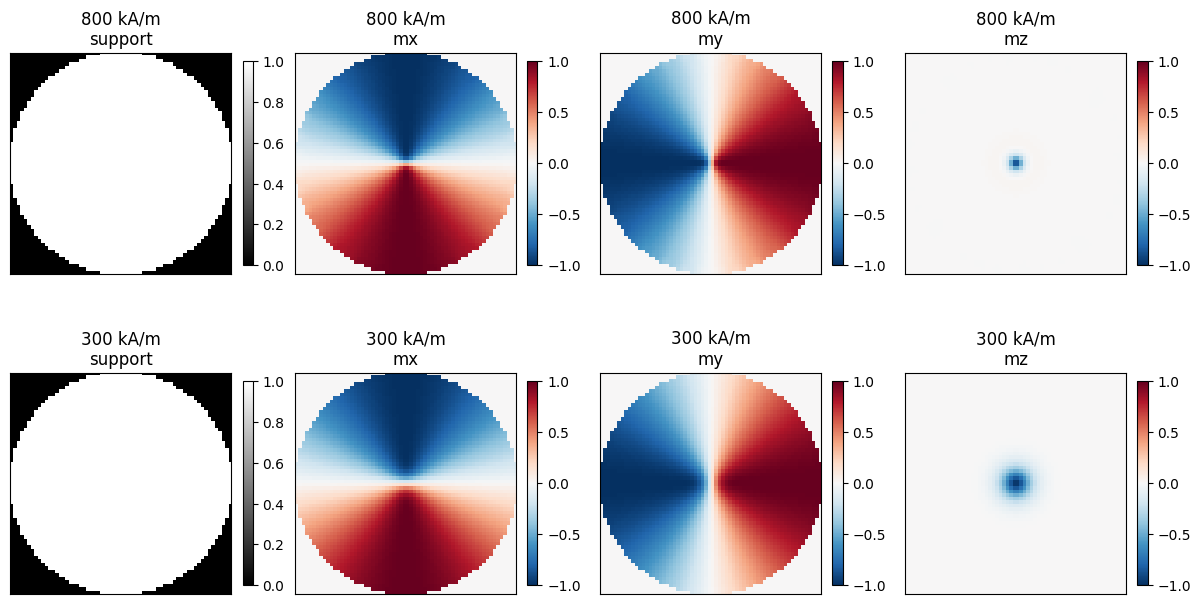

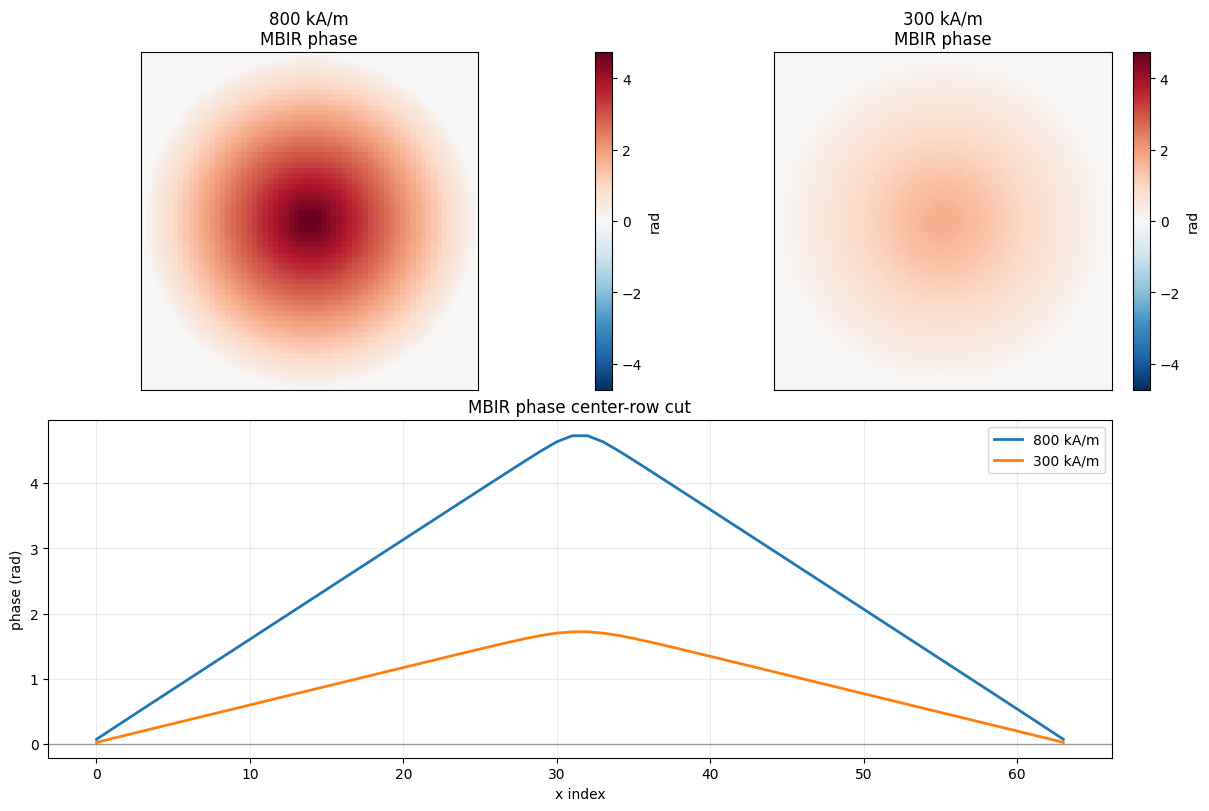

In [5]:
fig, axs = plt.subplots(len(results), 4, figsize=(12, 3.2 * len(results)), constrained_layout=True)
axs = np.atleast_2d(axs)

for row, (label, result) in enumerate(results.items()):
    rho = result["rho"]
    m = result["m"]
    mid = rho.shape[2] // 2
    panels = [
        (rho[:, :, mid].T, "support", "gray", 0.0, 1.0),
        (m[:, :, mid, 0].T, "mx", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 1].T, "my", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 2].T, "mz", "RdBu_r", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        im = axs[row, col].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[row, col].set_title(f"{label}\n{title}")
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        plt.colorbar(im, ax=axs[row, col], fraction=0.046)

plt.show()

phase_lim = max(max(abs(float(r["phase_yx"].min())), abs(float(r["phase_yx"].max()))) for r in results.values())
phase_lim = max(phase_lim, 1e-12)
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, len(results))

for col, (label, result) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(result["phase_yx"], cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"{label}\nMBIR phase")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

ax = fig.add_subplot(gs[1, :])
x_index = np.arange(shape_xyz[0])
for label, result in results.items():
    phase = result["phase_yx"]
    ax.plot(x_index, phase[phase.shape[0] // 2], linewidth=2.0, label=label)
ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.35)
ax.set_title("MBIR phase center-row cut")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## Differentiable `Msat` Fit

The fit treats `Msat` as the only unknown. A scalar unconstrained parameter `theta` is mapped through a sigmoid into `msat_bounds`, which keeps optimization inside a physically reasonable range without clipping gradients.

For every Adam step, the loss function:

1. maps `theta` to a bounded `Msat`;
2. runs a fixed-time NeuralMag LLG solve starting from the input magnetization;
3. converts the final node magnetization back to normalized cell vectors;
4. projects the magnetization to phase with the differentiable MBIR forward model;
5. returns mean squared phase residual against the target phase.

Because the solve and projection are both JAX-traceable here, `jax.value_and_grad()` can differentiate the phase loss with respect to the single scalar `theta`.


In [6]:
target = results[target_case]
source = results[input_case]
solver_dtype = jnp.float64

# Fixed arrays for the differentiable path. Keeping them as JAX arrays avoids
# host/device churn inside the jitted loss.
rho_xyz = jnp.asarray(target["rho"], dtype=solver_dtype)
support_cell = rho_xyz > 0.5

target_msat = float(target["Ms_A_per_m"])
input_msat = float(source["Ms_A_per_m"])
target_m_cell = jnp.asarray(target["m"], dtype=solver_dtype)
input_m_cell = jnp.asarray(source["m"], dtype=solver_dtype)
target_phase = jnp.asarray(target["phase_yx"], dtype=solver_dtype)
input_phase = jnp.asarray(
    phase_from_m_xyz(source["rho"], source["m"], input_msat, dtype=np.float64),
    dtype=solver_dtype,
)

# Build one parameterized NeuralMag state for the fit. The `parameters` argument
# below tells NeuralMag that `material__Ms` will be supplied when `solve()` runs.
fit_state = build_vortex_state(np.asarray(rho_xyz), np.asarray(input_m_cell), input_msat)
node_to_cell = fit_state.resolve(
    lambda f: nm.VectorFunction(fit_state, tensor=f).to_cell().tensor,
    ["f"],
)
rho_node = jnp.asarray(fit_state.rho.to_node().tensor, dtype=solver_dtype)
support_node = rho_node > 0.5

msat_min, msat_max = msat_bounds
input_fraction = np.clip(
    (input_msat - msat_min) / (msat_max - msat_min),
    1e-12,
    1.0 - 1e-12,
)
theta0 = jnp.asarray(np.log(input_fraction / (1.0 - input_fraction)), dtype=solver_dtype)
fit_times = jnp.asarray([0.0, llg_solve_time_s], dtype=solver_dtype)


def bounded_msat(theta):
    """Map an unconstrained optimizer variable to the allowed `Msat` interval."""
    return msat_min + (msat_max - msat_min) * jax.nn.sigmoid(theta)


def normalize_on_support(field, support):
    """Normalize vectors where the support mask is true and zero them elsewhere."""
    mask = support.astype(field.dtype)[..., None]
    eps = jnp.finfo(field.dtype).eps
    norm = jnp.sqrt(jnp.sum(field * field, axis=-1, keepdims=True) + eps**2)
    return mask * field / norm


def cell_from_node(m_node):
    """Convert NeuralMag node magnetization to cell magnetization for projection."""
    return normalize_on_support(
        node_to_cell(normalize_on_support(m_node, support_node)),
        support_cell,
    )


def phase_from_cell_jax(m_cell, msat):
    """Differentiable JAX phase projection for the current trial `Msat`."""
    m_xyz = normalize_on_support(m_cell, support_cell)
    reference_induction = reference_induction_from_msat(msat, dtype=solver_dtype)
    return phase_from_magnetisation(
        rho=rho_xyz,
        magnetization_3d=m_xyz,
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        reference_induction=reference_induction,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        axis="z",
        geometry="disc",
    )


fit_llg_solver = nm.LLGSolver(
    fit_state,
    parameters=["material__Ms"],
    max_steps=fit_llg_max_steps,
)
fit_llg_solver._dt0 = fit_llg_dt0_s


def relax(msat):
    """Run the differentiable inner LLG solve for a scalar `Msat` proposal."""
    return fit_llg_solver.solve(
        fit_times,
        jnp.full(rho_xyz.shape, msat, dtype=solver_dtype),
    ).ys[-1]


@jax.jit
def loss(theta):
    """Mean squared phase residual after evolving the input state at `Msat(theta)`."""
    msat = bounded_msat(theta)
    m_final = cell_from_node(relax(msat))
    residual = phase_from_cell_jax(m_final, msat) - target_phase
    return 0.5 * jnp.mean(residual * residual)


@jax.jit
def loss_and_grad(theta):
    """Jitted value-and-gradient wrapper used by the Adam loop."""
    return jax.value_and_grad(loss)(theta)


print(f"Target: {target_case} ({target_msat / 1e3:.0f} kA/m)")
print(f"Input:  {input_case} ({input_msat / 1e3:.0f} kA/m)")
print(f"Initial theta maps to {float(bounded_msat(theta0)) / 1e3:.1f} kA/m")
print(
    f"Inner differentiable LLG solve: time={llg_solve_time_s:.3e}s, "
    f"max_steps={fit_llg_max_steps}, dt0={fit_llg_dt0_s:.3e}s"
)

2026-05-06 10:11:40 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-05-06 10:11:40 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-06 10:11:40 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-05-06 10:11:40 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-06 10:11:40 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-06 10:11:40 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-06 10:11:42 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-05-06 10:11:42 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-05-06 10:11:42 NeuralMag:INFO [TotalField] Register state methods (field: 'h', 

Target: 800 kA/m (800 kA/m)
Input:  300 kA/m (300 kA/m)
Initial theta maps to 300.0 kA/m
Inner differentiable LLG solve: time=1.100e-10s, max_steps=4096, dt0=2.000e-14s


## Run The Optimizer

`run_adam()` calls the jitted loss once to pay the JAX compilation cost up front, then runs the requested number of Adam updates. The recorded history stores the current bounded `Msat`, phase RMS, and elapsed optimizer time for plotting.

The RMS printed during the loop is computed from the loss before the current update, so it describes the trial that produced the gradient. The final report recomputes the phase prediction after the last update.


In [7]:
def run_adam(theta, *, steps=outer_steps, learning_rate=outer_learning_rate):
    """Optimize the scalar `theta` parameter and return fit diagnostics."""
    opt = optax.adam(learning_rate)
    opt_state = opt.init(theta)
    history = []

    # The first jitted call includes compilation. Measure it separately so the
    # optimizer timing reflects repeated execution rather than one-time tracing.
    started = time.perf_counter()
    warmup_loss, _ = loss_and_grad(theta)
    jax.block_until_ready(warmup_loss)
    compile_elapsed_s = time.perf_counter() - started

    started = time.perf_counter()
    for step in range(int(steps)):
        print(f"Step {step + 1}/{steps} ...")
        loss_value, grad = loss_and_grad(theta)
        updates, opt_state = opt.update(grad, opt_state, theta)
        theta = optax.apply_updates(theta, updates)

        msat = float(jax.device_get(bounded_msat(theta)))
        phase_rms = float(jax.device_get(jnp.sqrt(2.0 * loss_value)))
        history.append(
            {
                "step": step,
                "msat": msat,
                "phase_rms": phase_rms,
                "elapsed_s": time.perf_counter() - started,
            }
        )
        print(f"  {step + 1:2d}/{steps}: Msat={msat / 1e3:8.2f} kA/m | phase RMS={phase_rms:.6g}")

    msat_final = bounded_msat(theta)
    m_final_node = relax(msat_final)
    m_final = cell_from_node(m_final_node)
    phase_pred = phase_from_cell_jax(m_final, msat_final)
    residual = phase_pred - target_phase

    return {
        "theta": theta,
        "msat": float(jax.device_get(msat_final)),
        "phase_rms": float(jax.device_get(jnp.sqrt(jnp.mean(residual * residual)))),
        "phase_pred": np.asarray(jax.device_get(phase_pred)),
        "m_cell_final": np.asarray(jax.device_get(m_final)),
        "history": history,
        "compile_elapsed_s": compile_elapsed_s,
        "optimizer_elapsed_s": history[-1]["elapsed_s"] if history else 0.0,
    }


fit_result = run_adam(theta0)
print(
    f"Final Msat={fit_result['msat'] / 1e3:.2f} kA/m | "
    f"phase RMS={fit_result['phase_rms']:.6g} rad | "
    f"compile={fit_result['compile_elapsed_s']:.2f}s, optimize={fit_result['optimizer_elapsed_s']:.2f}s"
)


Step 1/10 ...
   1/10: Msat=  313.88 kA/m | phase RMS=1.10901
Step 2/10 ...
   2/10: Msat=  329.35 kA/m | phase RMS=1.07818
Step 3/10 ...
   3/10: Msat=  346.51 kA/m | phase RMS=1.04382
Step 4/10 ...
   4/10: Msat=  365.44 kA/m | phase RMS=1.00572
Step 5/10 ...
   5/10: Msat=  386.19 kA/m | phase RMS=0.963698
Step 6/10 ...
   6/10: Msat=  408.76 kA/m | phase RMS=0.917655
Step 7/10 ...
   7/10: Msat=  433.11 kA/m | phase RMS=0.867574
Step 8/10 ...
   8/10: Msat=  459.11 kA/m | phase RMS=0.813561
Step 9/10 ...
   9/10: Msat=  486.59 kA/m | phase RMS=0.755869
Step 10/10 ...
  10/10: Msat=  515.26 kA/m | phase RMS=0.694924
Final Msat=515.26 kA/m | phase RMS=0.631341 rad | compile=78.30s, optimize=134.80s


## Diagnostics

The final cell turns the fit into visual checks:

1. optimizer traces for phase RMS, `Msat`, and wall time;
2. side-by-side input, target, and fitted magnetization/phase panels;
3. residual maps and center-row phase profiles.

A successful short run should move `Msat` in the right direction and reduce the phase mismatch. Exact recovery is not expected with only a handful of outer steps and a short fixed-time inner solve.


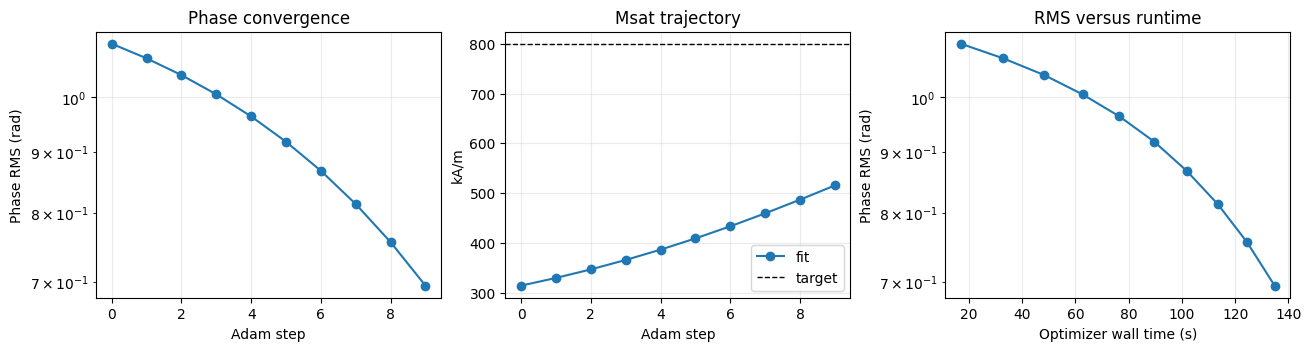

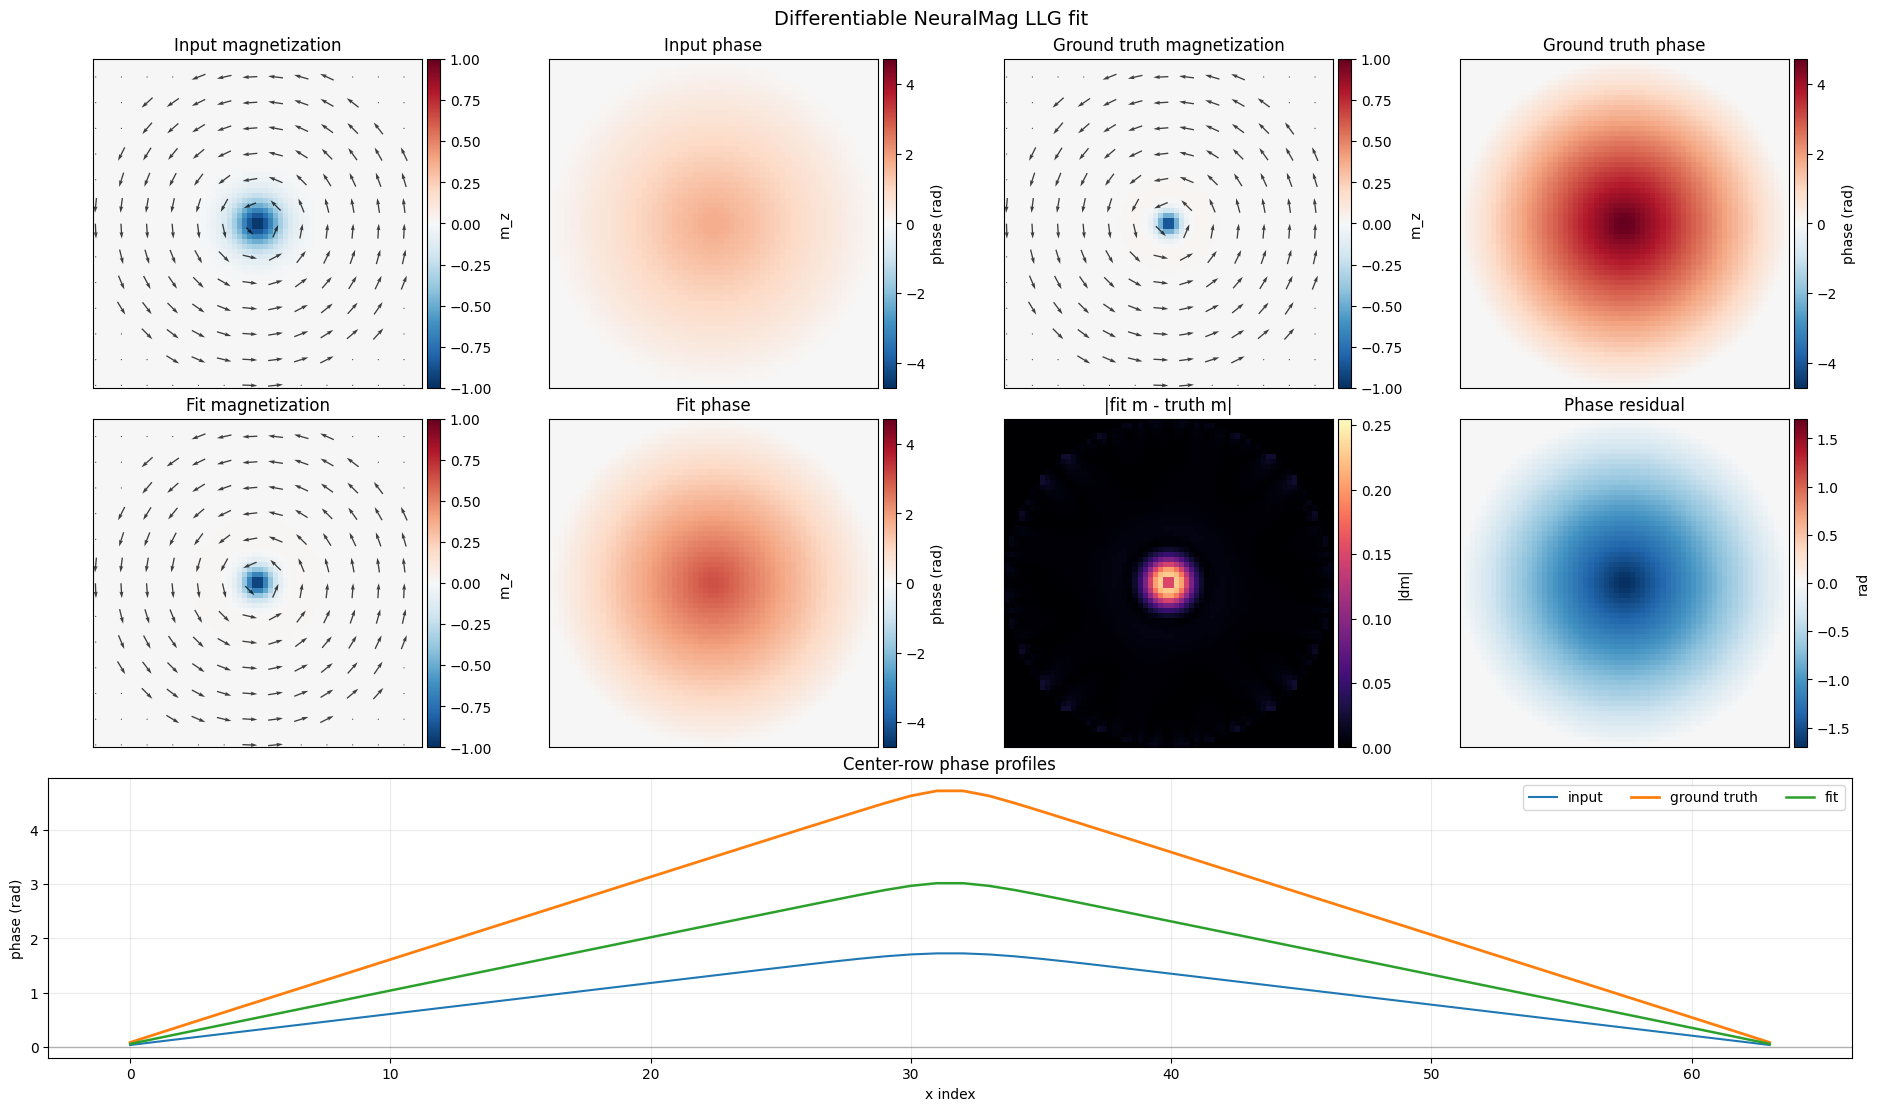

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def as_np(value):
    """Move JAX values to host NumPy arrays for plotting."""
    return np.asarray(jax.device_get(value), dtype=np.float64)


def add_colorbar(ax, im, label):
    """Attach a compact colorbar next to an image axis."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(label)


def show_m_slice(ax, m_cell, title, *, quiver_step=5):
    """Show mid-plane `m_z` with in-plane arrows overlaid."""
    mid = m_cell.shape[2] // 2
    im = ax.imshow(m_cell[:, :, mid, 2].T, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    x = np.arange(0, m_cell.shape[0], quiver_step)
    y = np.arange(0, m_cell.shape[1], quiver_step)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    ax.quiver(
        xx,
        yy,
        m_cell[::quiver_step, ::quiver_step, mid, 0].T,
        m_cell[::quiver_step, ::quiver_step, mid, 1].T,
        color="k",
        pivot="mid",
        scale=22,
        width=0.004,
        alpha=0.75,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def show_phase(ax, phase, title, limit):
    """Show a phase image with a symmetric color scale."""
    im = ax.imshow(phase, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


history = fit_result["history"]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
steps = np.array([row["step"] for row in history])
rms = np.array([row["phase_rms"] for row in history])
msat = np.array([row["msat"] for row in history])
elapsed = np.array([row["elapsed_s"] for row in history])

axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o")
axs[0].set_title("Phase convergence")
axs[0].set_xlabel("Adam step")
axs[0].set_ylabel("Phase RMS (rad)")
axs[0].grid(True, alpha=0.25)

axs[1].plot(steps, msat / 1e3, marker="o", label="fit")
axs[1].axhline(target_msat / 1e3, color="k", ls="--", lw=1.0, label="target")
axs[1].set_title("Msat trajectory")
axs[1].set_xlabel("Adam step")
axs[1].set_ylabel("kA/m")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].semilogy(np.maximum(elapsed, 1e-9), np.maximum(rms, 1e-30), marker="o")
axs[2].set_title("RMS versus runtime")
axs[2].set_xlabel("Optimizer wall time (s)")
axs[2].set_ylabel("Phase RMS (rad)")
axs[2].grid(True, alpha=0.25)
plt.show()

input_m_np = as_np(input_m_cell)
target_m_np = as_np(target_m_cell)
fit_m_np = as_np(fit_result["m_cell_final"])
input_phase_np = as_np(input_phase)
target_phase_np = as_np(target_phase)
fit_phase_np = as_np(fit_result["phase_pred"])
phase_resid_np = fit_phase_np - target_phase_np
m_error_np = np.linalg.norm(fit_m_np - target_m_np, axis=-1)

phase_lim = max(abs(float(arr.min())) for arr in (input_phase_np, target_phase_np, fit_phase_np))
phase_lim = max(phase_lim, max(abs(float(arr.max())) for arr in (input_phase_np, target_phase_np, fit_phase_np)), 1e-12)
resid_lim = max(abs(float(phase_resid_np.min())), abs(float(phase_resid_np.max())), 1e-12)
merr_lim = max(float(np.nanmax(m_error_np)), 1e-12)

fig = plt.figure(figsize=(18.5, 11.0), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.0, 0.85])
fig.suptitle("Differentiable NeuralMag LLG fit", fontsize=14)

panels = [
    (0, 0, show_m_slice, input_m_np, "Input magnetization", "m_z", None),
    (0, 1, show_phase, input_phase_np, "Input phase", "phase (rad)", phase_lim),
    (0, 2, show_m_slice, target_m_np, "Ground truth magnetization", "m_z", None),
    (0, 3, show_phase, target_phase_np, "Ground truth phase", "phase (rad)", phase_lim),
    (1, 0, show_m_slice, fit_m_np, "Fit magnetization", "m_z", None),
    (1, 1, show_phase, fit_phase_np, "Fit phase", "phase (rad)", phase_lim),
]

for row, col, plot_fn, values, title, cbar_label, limit in panels:
    ax = fig.add_subplot(gs[row, col])
    im = plot_fn(ax, values, title) if limit is None else plot_fn(ax, values, title, limit)
    add_colorbar(ax, im, cbar_label)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(m_error_np[:, :, m_error_np.shape[2] // 2].T, cmap="magma", vmin=0.0, vmax=merr_lim)
ax.set_title("|fit m - truth m|")
ax.set_xticks([])
ax.set_yticks([])
add_colorbar(ax, im, "|dm|")

ax = fig.add_subplot(gs[1, 3])
im = show_phase(ax, phase_resid_np, "Phase residual", resid_lim)
add_colorbar(ax, im, "rad")

ax = fig.add_subplot(gs[2, :])
x_index = np.arange(target_phase_np.shape[1])
row = target_phase_np.shape[0] // 2
ax.plot(x_index, input_phase_np[row], lw=1.5, label="input")
ax.plot(x_index, target_phase_np[row], lw=2.0, label="ground truth")
ax.plot(x_index, fit_phase_np[row], lw=1.8, label="fit")
ax.axhline(0.0, color="k", lw=1.0, alpha=0.25)
ax.set_title("Center-row phase profiles")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, loc="best")
plt.show()


# Conclusion

The results shows that the approach of differentiating through the LLG equation with a fixed number of steps, and a forward phase function is theoretically feasible. However, the approach is somewhat impractical because the computation is quite slow, and we for now need to differentiate through a fixed step LLG solve, which is not ideal because we are not guaranteed to have converged to a minimum.